# PROJET D’ÉCONOMÉTRIE APPLIQUÉE

In [109]:
# imprtation des librairies
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from scipy.stats import chi2
from sklearn.linear_model import LinearRegression

# Import des librairies supplémentaires
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split, KFold
from sklearn.metrics import mean_squared_error



In [110]:
# imprtation du jeux de données
df = pd.read_excel('donnees_immobilieres.xlsx')

In [111]:
# suppression de la collone ID et affiche du dataFrame
df = df.drop(columns=["ID"])
columns_var = df.columns
df

,Surface_m2,Chambres,Annee_construction,Distance_centre_km,Etage,Ascenseur,Annee_vente,Qualite_ecole,Revenu_median_quartier,Distance_universite,Prix_milliers_euros
0,139.87,3,1982,21.33,2,1,2023,1.1,47.5,11.9,1961.68
1,114.47,4,1991,2.90,5,1,2022,4.7,44.2,11.9,2303.67
2,145.91,2,2005,3.00,3,1,2017,3.2,53.8,10.7,2224.12
3,180.92,4,1995,29.61,3,1,2022,6.1,68.3,11.1,2425.63
4,110.63,3,2016,11.54,0,0,2021,9.0,81.9,10.8,2323.34
...,...,...,...,...,...,...,...,...,...,...,...
145,151.27,3,1992,10.20,1,0,2019,4.6,51.3,6.7,2140.32
146,70.52,2,2019,19.19,2,0,2016,4.1,42.9,3.7,1680.16
147,67.18,1,2021,7.58,4,0,2019,5.4,71.6,8.7,1902.30
148,140.88,3,1988,2.74,3,0,2020,5.0,54.4,9.5,2252.99


In [112]:
# infos utiles
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Surface_m2              150 non-null    float64
 1   Chambres                150 non-null    int64  
 2   Annee_construction      150 non-null    int64  
 3   Distance_centre_km      150 non-null    float64
 4   Etage                   150 non-null    int64  
 5   Ascenseur               150 non-null    int64  
 6   Annee_vente             150 non-null    int64  
 7   Qualite_ecole           150 non-null    float64
 8   Revenu_median_quartier  150 non-null    float64
 9   Distance_universite     150 non-null    float64
 10  Prix_milliers_euros     150 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 13.0 KB


In [113]:
# Les statistics desciptives
stats_base = df.describe()
stats_base.drop('count')
print(stats_base)

       Surface_m2    Chambres  Annee_construction  Distance_centre_km  \
count  150.000000  150.000000          150.000000          150.000000   
mean   116.706800    2.886667         2001.826667           16.500267   
std     37.693819    1.077760           11.704841            9.017430   
min     15.210000    1.000000         1980.000000            0.830000   
25%     93.240000    2.000000         1991.000000            9.105000   
50%    117.845000    3.000000         2002.500000           16.865000   
75%    139.637500    4.000000         2012.000000           24.697500   
max    218.530000    5.000000         2022.000000           29.990000   

            Etage   Ascenseur  Annee_vente  Qualite_ecole  \
count  150.000000  150.000000   150.000000     150.000000   
mean     2.580000    0.460000  2019.840000       5.468667   
std      1.761901    0.500067     2.288225       1.868249   
min      0.000000    0.000000  2015.000000       1.000000   
25%      1.000000    0.000000  2018.0

In [114]:
# aves l'asymétrie et l'applatissement du prix
skew_prix = df["Prix_milliers_euros"].skew()
kurt_prix = df["Prix_milliers_euros"].kurt()

print(f'\nAsymétrie (skewness) du prix :{skew_prix:.3f}')
print(f'Aplatissement (kurtosis) du prix :{kurt_prix:.3f}')




Asymétrie (skewness) du prix :0.156
Aplatissement (kurtosis) du prix :-0.469


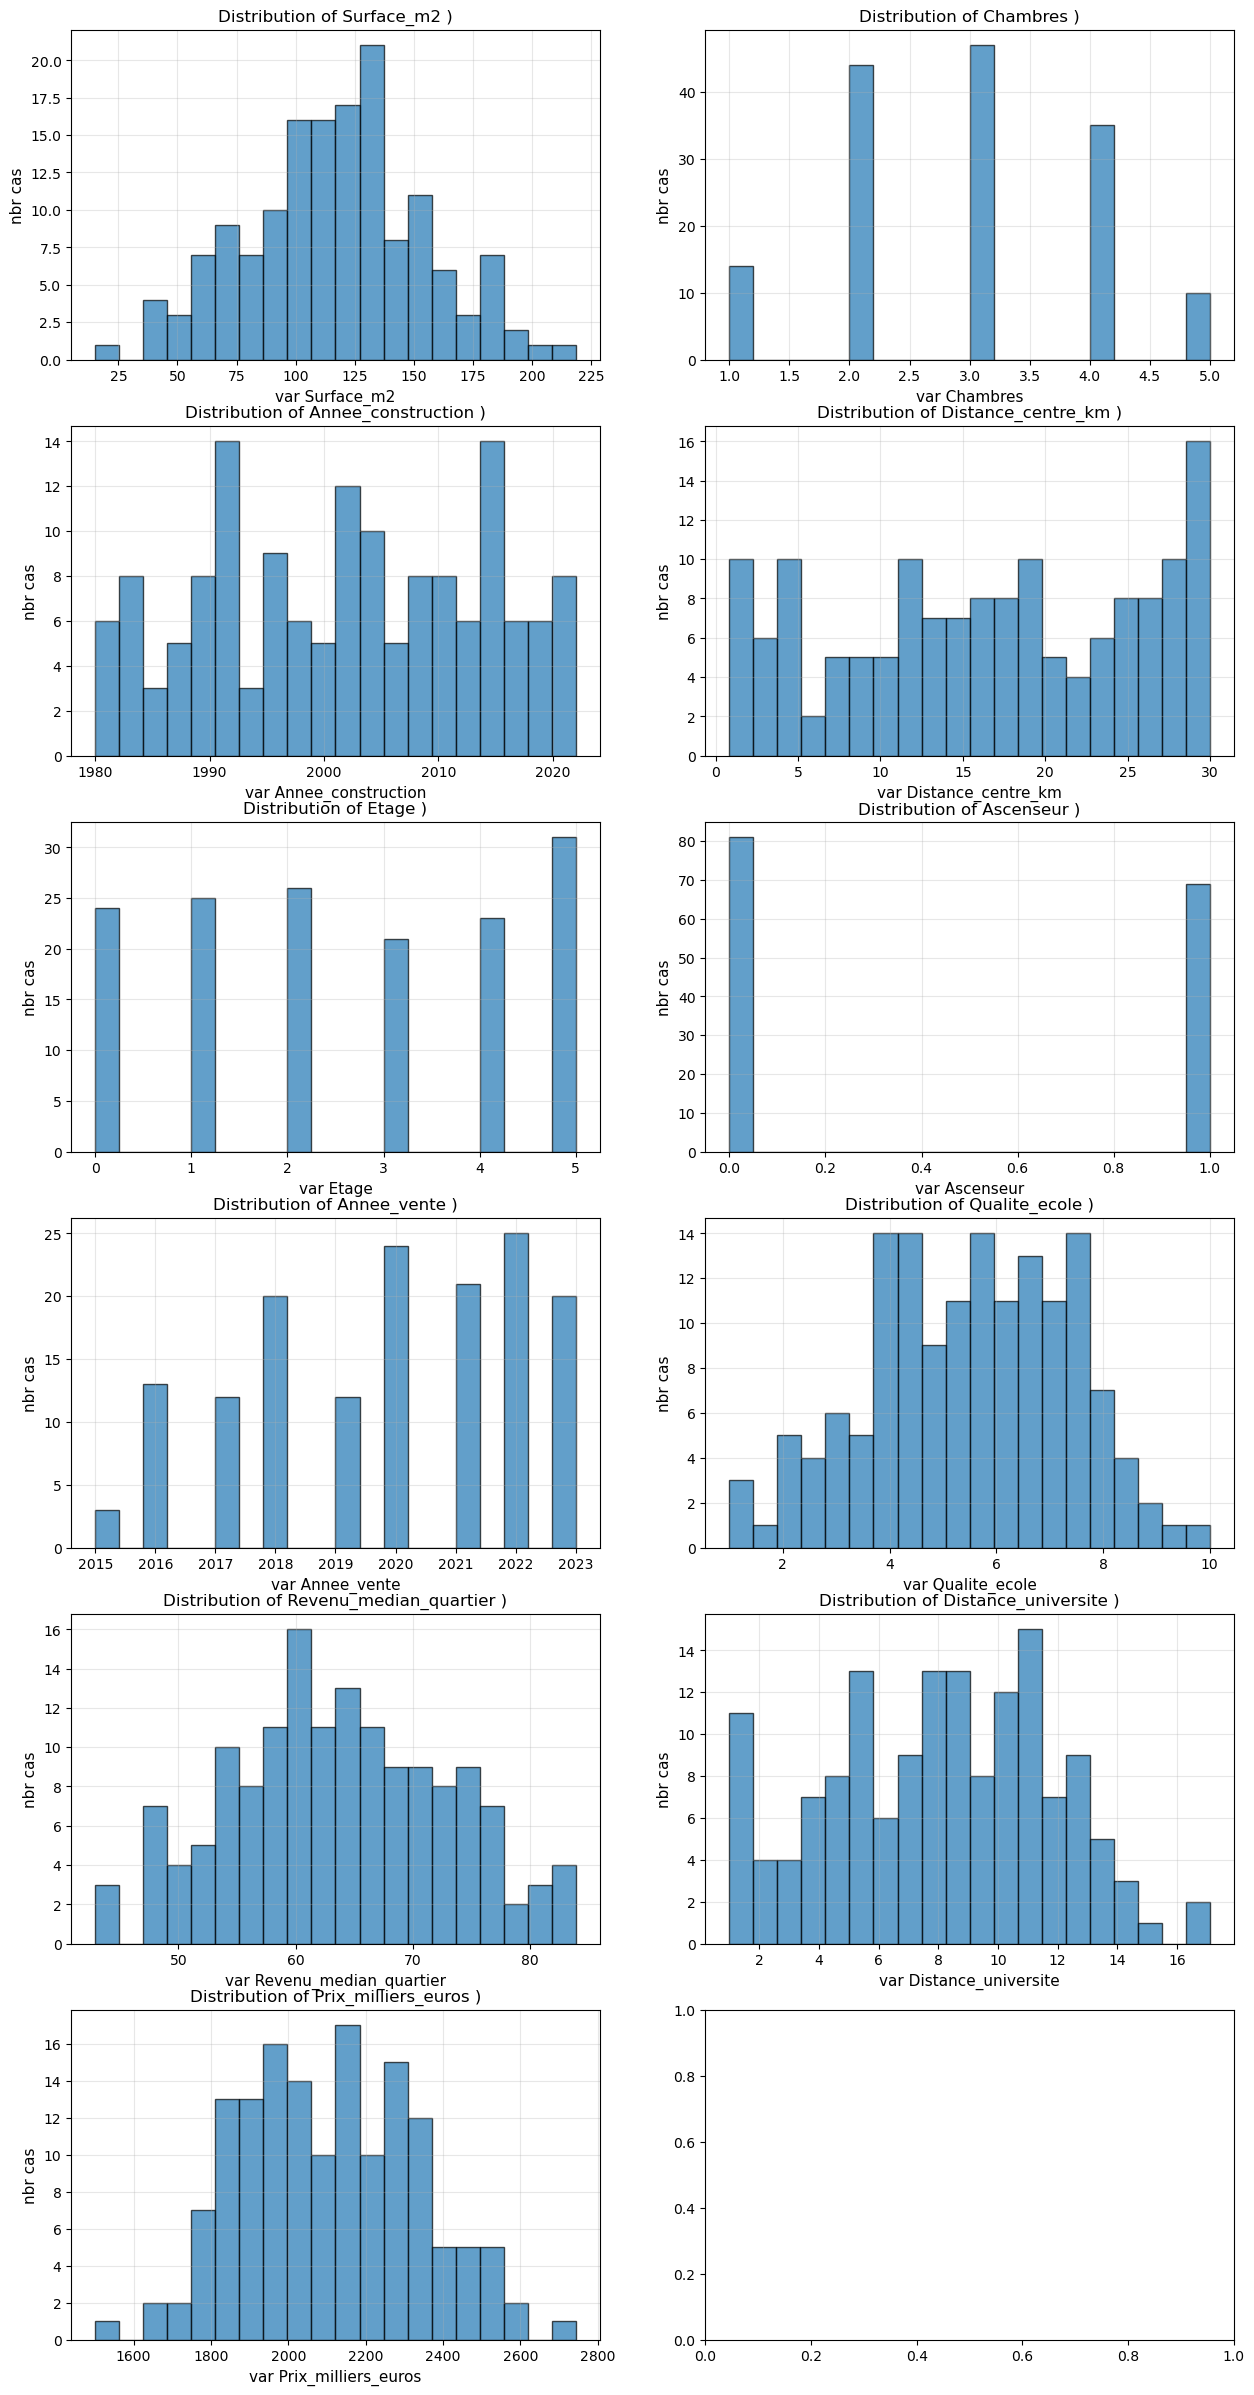

In [115]:
# création des histogrammes
fig_line = 6
fig_col = 2
fig, axes = plt.subplots(fig_line, fig_col, figsize=(15, 30))
k=0

for i in range(fig_line):
    for j in range(fig_col):
        if k < 11 :
            var = columns_var[k]
            axes[i, j].hist(df[var], bins=20, edgecolor='black', alpha=0.7)
            axes[i, j].set_xlabel(f'var {var}', fontsize=11)
            axes[i, j].set_ylabel('nbr cas', fontsize=11)
            axes[i, j].set_title(f'Distribution of {var} )', fontsize=12)
            axes[i, j].grid(True, alpha=0.3)
            k += 1


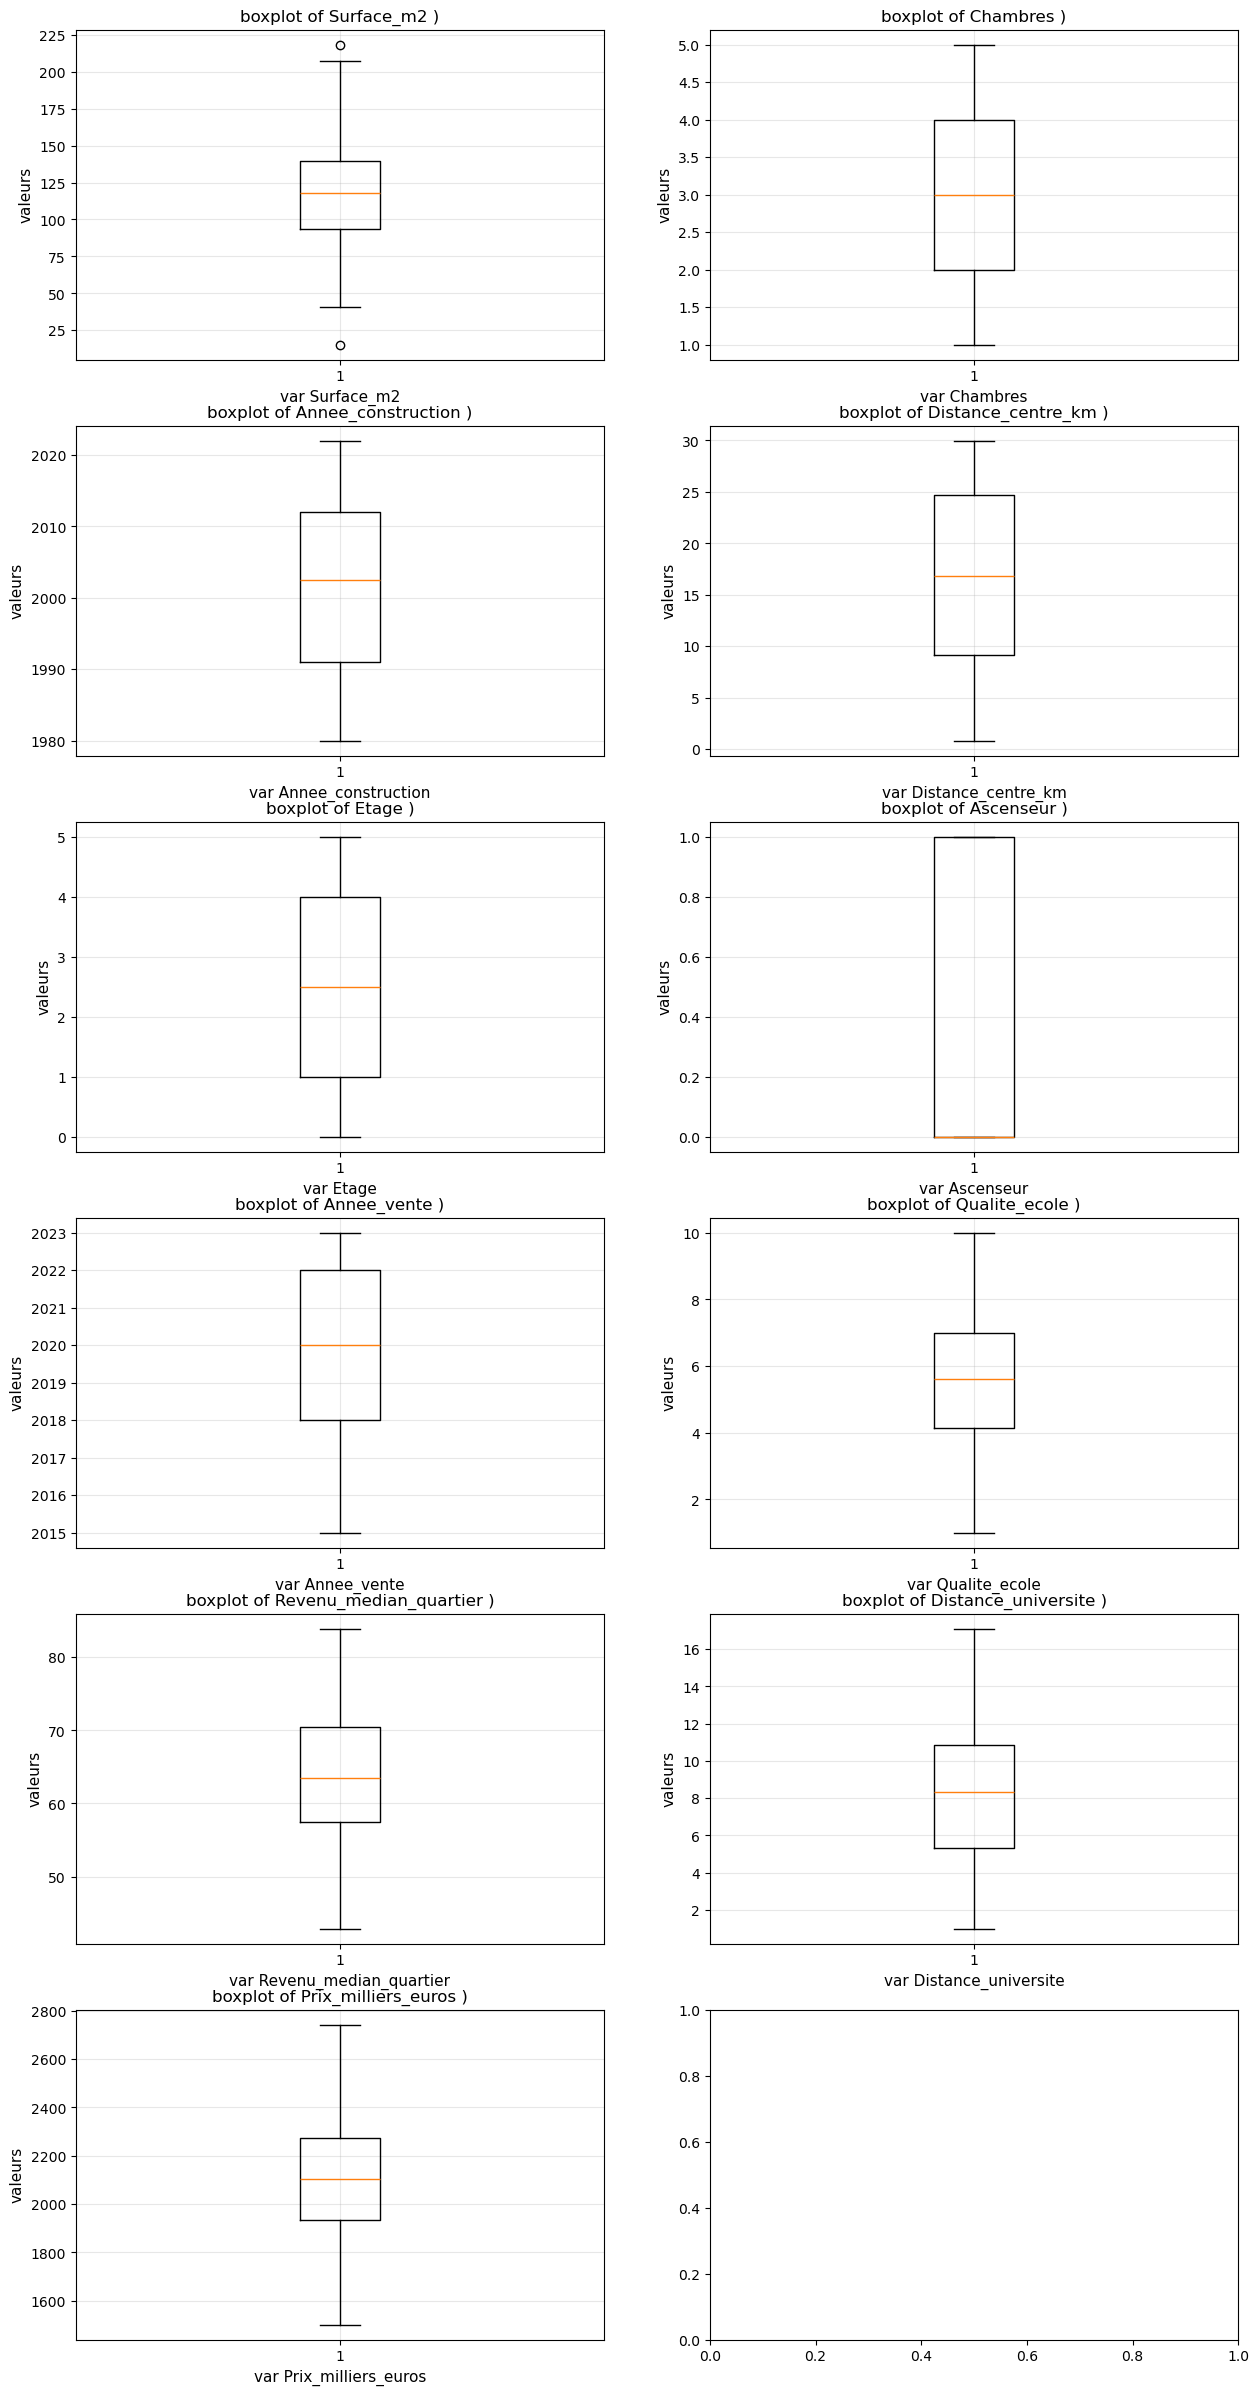

In [116]:
# création des boites à moustache
fig, axes = plt.subplots(fig_line, fig_col, figsize=(15, 30))
k=0

for i in range(fig_line):
    for j in range(fig_col):
        if k < 11 :
            var = columns_var[k]
            axes[i, j].boxplot(df[var])
            axes[i, j].set_xlabel(f'var {var}', fontsize=11)
            axes[i, j].set_ylabel('valeurs', fontsize=11)
            axes[i, j].set_title(f'boxplot of {var} )', fontsize=12)
            axes[i, j].grid(True, alpha=0.3)
            k += 1

### Corrélations

In [117]:
# corrélations de Person
corr = df.corr()
print(corr)

                        Surface_m2  Chambres  Annee_construction  \
Surface_m2                1.000000  0.590959           -0.034333   
Chambres                  0.590959  1.000000            0.039398   
Annee_construction       -0.034333  0.039398            1.000000   
Distance_centre_km       -0.074765 -0.102319           -0.088117   
Etage                     0.061126  0.048986           -0.044559   
Ascenseur                -0.062416 -0.014694           -0.100949   
Annee_vente               0.060417  0.036140           -0.055920   
Qualite_ecole             0.043832 -0.012775           -0.009887   
Revenu_median_quartier    0.013908  0.011761            0.030304   
Distance_universite      -0.088362 -0.089609           -0.006250   
Prix_milliers_euros       0.826731  0.614825            0.068358   

                        Distance_centre_km     Etage  Ascenseur  Annee_vente  \
Surface_m2                       -0.074765  0.061126  -0.062416     0.060417   
Chambres               

In [118]:
len(corr.columns)

11

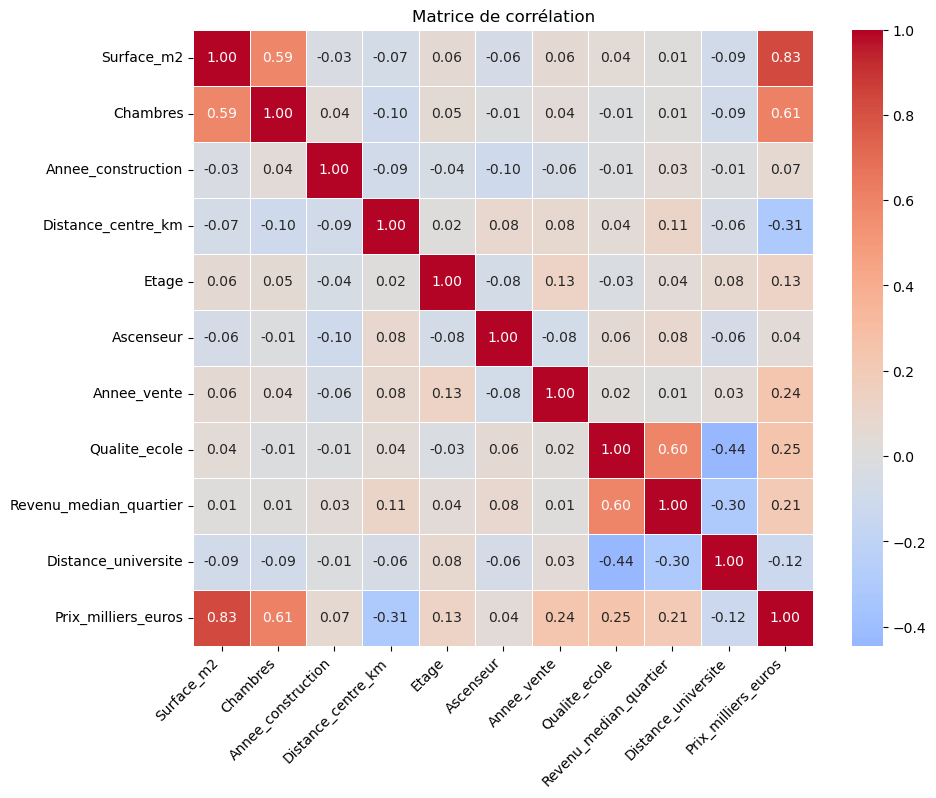

In [119]:

# graphique de corrélation avec des couleurs (avec seaborn vu en Data M)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.xticks(rotation=45, ha="right")
plt.title("Matrice de corrélation")
plt.show()

 ### Le Modèle Linéaire

In [120]:
#### Obtention des coefficients avec la méthode des moindres carrés (MCO) ###

N = 150
x = df['Surface_m2']
y = df['Prix_milliers_euros']

# moyennes
x_bar = np.mean(x)
y_bar = np.mean(y)

# coefficient directeur estimé
numerator = np.sum((x - x_bar) * (y - y_bar))
denominator = np.sum((x - x_bar)**2)
b1_hat = numerator / denominator

# valeur x=0 origine estimé
b0_hat = y_bar - b1_hat * x_bar

# y estimé
y_hat = b0_hat + b1_hat * x

# calcul des erreurs
u_hat = y - y_hat


# calcul de R² avec les 2 méhodes
SST = np.sum((y - y_bar)**2)
SSR = np.sum((y_hat - y_bar)**2)
SSE = np.sum(u_hat**2)

R2_method1 = SSR / SST
R2_method2 = 1 - SSE / SST

print("calcul des coefficients MCO :")
print(f"b0_hat = {b0_hat:.4f}")
print(f"b1_hat = {b1_hat:.4f}")
print(f"\nMoyenn des erreurs: {np.mean(u_hat):.14f} (should be ≈ 0)")

print("\nAnalyse de la variance R²:")
print(f"SST (Total de la somme des carrés): {SST:.4f}")
print(f"SSR (Total de la somme des carrés estimé): {SSR:.4f}")
print(f"SSE (Somme des erreur au carré): {SSE:.4f}")
print(f"\nVerification: SST = SSR + SSE?")
print(f"{SST:.4f} = {SSR:.4f} + {SSE:.4f} = {SSR + SSE:.4f}")
print(f"\nR² (Methode 1: SSR/SST): {R2_method1:.4f}")
print(f"R² (Methode 2: 1 - SSE/SST): {R2_method2:.4f}")
print(f"\nInterpretation: {R2_method1*100:.2f}% de la variance dans y est expliquée par x")


calcul des coefficients MCO :
b0_hat = 1519.3743
b1_hat = 5.0428

Moyenn des erreurs: 0.00000000000004 (should be ≈ 0)

Analyse de la variance R²:
SST (Total de la somme des carrés): 7876687.1845
SSR (Total de la somme des carrés estimé): 5383592.2807
SSE (Somme des erreur au carré): 2493094.9039

Verification: SST = SSR + SSE?
7876687.1845 = 5383592.2807 + 2493094.9039 = 7876687.1845

R² (Methode 1: SSR/SST): 0.6835
R² (Methode 2: 1 - SSE/SST): 0.6835

Interpretation: 68.35% de la variance dans y est expliquée par x


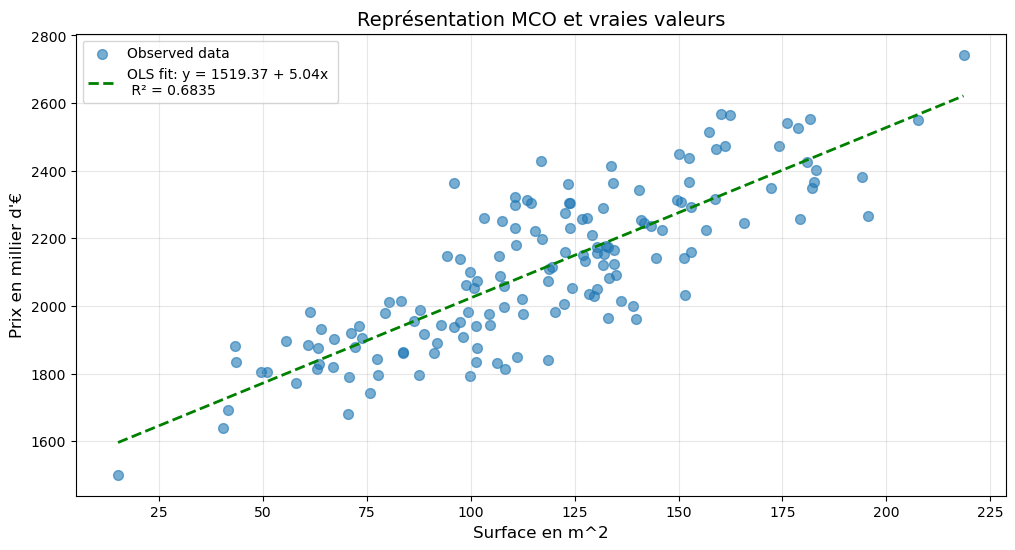

In [121]:
# représentation de la distribution, l'équation de la droite et R² + R² ajusté

plt.figure(figsize=(12, 6))

sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_hat_sorted = y_hat[sort_idx]

plt.scatter(x, y, alpha=0.6, label='Observed data', s=50)
plt.plot(x_sorted, y_hat_sorted, 'g--', 
         label=f'OLS fit: y = {b0_hat:.2f} + {b1_hat:.2f}x \n R² = {R2_method1:.4f}', linewidth=2)



plt.xlabel('Surface en m^2', fontsize=12)
plt.ylabel('Prix en millier d\'€', fontsize=12)
plt.title('Représentation MCO et vraies valeurs', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [122]:

# L’écart-type de chaque coefficient (ˆσˆβj)
# La statistique t et la p-valeur

sigma_squared_hat = np.sum(u_hat**2) / (N - 2)
var_b1_hat = sigma_squared_hat / np.sum((x - x_bar)**2)
var_b0_hat = (sigma_squared_hat / N) + (x_bar**2 * var_b1_hat)
se_b1_hat = np.sqrt(var_b1_hat)
se_b0_hat = np.sqrt(var_b0_hat)

# t statistique
t_stat_b0 = b0_hat / se_b0_hat
t_stat_b1 = b1_hat / se_b1_hat

# p-values
p_value_b0 = 2 * (1 - stats.t.cdf(abs(t_stat_b0), N - 2))
p_value_b1 = 2 * (1 - stats.t.cdf(abs(t_stat_b1), N - 2))

print("Variance et estimateurs pour les coefficients beta:\n")
print(f"Estimation du sigma écart type σ²: {sigma_squared_hat:.4f}")
print(f"\n Paramètres estimés :")
print(f"b0_hat = {b0_hat:.4f}, SE = {se_b0_hat:.4f}, t = {t_stat_b0:.4f}, p-value = {p_value_b0:.4f}")
print(f"b1_hat = {b1_hat:.4f}, SE = {se_b1_hat:.4f}, t = {t_stat_b1:.4f}, p-value = {p_value_b1:.4f}")

# Interval de certitude à 95%
t_critical = stats.t.ppf(0.975, N - 2)
ci_b0 = (b0_hat - t_critical * se_b0_hat, b0_hat + t_critical * se_b0_hat)
ci_b1 = (b1_hat - t_critical * se_b1_hat, b1_hat + t_critical * se_b1_hat)

print(f"\nInyervale de certitude à 95%:")
print(f"b0: [{ci_b0[0]:.4f}, {ci_b0[1]:.4f}]")
print(f"b1: [{ci_b1[0]:.4f}, {ci_b1[1]:.4f}]")

Variance et estimateurs pour les coefficients beta:

Estimation du sigma écart type σ²: 16845.2358

 Paramètres estimés :
b0_hat = 1519.3743, SE = 34.5845, t = 43.9323, p-value = 0.0000
b1_hat = 5.0428, SE = 0.2821, t = 17.8771, p-value = 0.0000

Inyervale de certitude à 95%:
b0: [1451.0311, 1587.7175]
b1: [4.4854, 5.6002]


## Régression Multiple paramètres 

In [123]:
# Forme matricielle
X = np.column_stack((
    np.ones(N),         
    df["Surface_m2"],
    df["Chambres"],
    df["Annee_construction"],
    df["Distance_centre_km"],
    df["Etage"],
    df["Ascenseur"]
))
# Y matriciel
Y = df["Prix_milliers_euros"].to_numpy()
Y = np.asarray(Y).reshape(-1)   # garantit shape (n,)

# matrice beta estimé
XtX_inv = np.linalg.inv(X.T @ X)
B_hat = XtX_inv @ X.T @ Y

print("Résultats de la régression linéaire multiple:\n")
print("Valeurs des coefficients:\n")
print(f"b0_constant = {B_hat[0]:.4f}")
print(f"b1_Surface_m2 = {B_hat[1]:.4f}")
print(f"b2_Chambres = {B_hat[2]:.4f}")
print(f"b3_Annee_construction = {B_hat[3]:.4f}")
print(f"b4_Distance_centre_km = {B_hat[4]:.4f}")
print(f"b5_Etage = {B_hat[5]:.4f}")
print(f"b6_Ascenseur = {B_hat[6]:.4f}")

# Calcul matriciel des erreurs
Y_hat = X @ B_hat
U_hat = Y - Y_hat

# Calcul matriciel de R²
SST_multi = np.sum((Y - np.mean(Y))**2)
SSE_multi = np.sum(U_hat**2)
R2_multi = 1 - SSE_multi / SST_multi

# Calcul matriciel de R² ajusté
k = X.shape[1]
R2_adj_multi = 1 - (N - 1) / (N - k) * (1 - R2_multi)

print(f"\nR² = {R2_multi:.4f}")
print(f"R² ajusté = {R2_adj_multi:.4f}")

Résultats de la régression linéaire multiple:

Valeurs des coefficients:

b0_constant = -1679.4908
b1_Surface_m2 = 4.3879
b2_Chambres = 33.9205
b3_Annee_construction = 1.6093
b4_Distance_centre_km = -6.1446
b5_Etage = 12.2540
b6_Ascenseur = 55.5141

R² = 0.7887
R² ajusté = 0.7798


In [124]:
model_multi = sm.OLS(Y, X).fit()
print("Statsmodels OLS Summary:")
print(model_multi.summary())

# Compare estimates
print("\n" + "="*60)
print("Comparison of estimates:")
print("="*60)
print(f"{'Parameter':<12} {'Manual':<12} {'Statsmodels':<12} {'Difference':<12}")
print("-"*60)
for i in range(len(B_hat)):
    diff = abs(B_hat[i] - model_multi.params[i])
    print(f"b{i:<11} {B_hat[i]:<12.6f} {model_multi.params[i]:<12.6f} {diff:<12.8f}")

Statsmodels OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     88.94
Date:                Wed, 31 Dec 2025   Prob (F-statistic):           9.10e-46
Time:                        12:51:14   Log-Likelihood:                -911.43
No. Observations:                 150   AIC:                             1837.
Df Residuals:                     143   BIC:                             1858.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1679.4908   153

### Transformation logarithmique

In [125]:
# Transformer les matrices en log
models = {}
#Y_log
Y_log = np.log(Y)
#X_log
X_linlog = X.copy()
# log(Surface)
X_linlog[:, 1] = np.log(X_linlog[:, 1])
# log(Distance)
X_linlog[:, 4] = np.log(X_linlog[:, 4])

models["linear-linear"] = sm.OLS(Y, X).fit()
models["log-linear"] = sm.OLS(Y_log, X).fit()
models["linear-log"] = sm.OLS(Y, X_linlog).fit()
models["log-log"] = sm.OLS(Y_log, X_linlog).fit()

print("Model Comparison:\n")
for name, model in models.items():
    print(f"{name:15} R² = {model.rsquared:.4f}")
    print(f"                Coefficients: b0 = {model.params[0]:.4f}, b1 = {model.params[1]:.4f}")
    print()

Model Comparison:

linear-linear   R² = 0.7887
                Coefficients: b0 = -1679.4908, b1 = 4.3879

log-linear      R² = 0.7916
                Coefficients: b0 = 5.8413, b1 = 0.0021

linear-log      R² = 0.7365
                Coefficients: b0 = -1955.3942, b1 = 382.3162

log-log         R² = 0.7546
                Coefficients: b0 = 5.6693, b1 = 0.1898



## Calcul des VIFs

In [126]:
var_names = ["Constante", "Surface_m2", "Chambres", "Annee_construction",
             "Distance_centre_km", "Etage", "Ascenseur"]

# Fonction R² : régression de x_j sur X_{-j}
def r2_auxiliary(x_j, X_others):
    # Estimation OLS via least squares
    beta_j, *_ = np.linalg.lstsq(X_others, x_j, rcond=None)
    x_hat = X_others @ beta_j
    sse = np.sum((x_j - x_hat)**2)
    sst = np.sum((x_j - np.mean(x_j))**2)
    return 1 - sse / sst

# Calcul des VIF
vif = {}

# On saute la constante 
for j in range(1, X.shape[1]):
    x_j = X[:, j]
    
    # X_others = toutes les colonnes sauf j
    X_others = np.delete(X, j, axis=1)
    
    R2_j = r2_auxiliary(x_j, X_others)
    vif_j = 1 / (1 - R2_j)
    
    vif[var_names[j]] = {"R2_aux": R2_j, "VIF": vif_j}


print("VIF (Variance Inflation Factor) :\n")
for name, vals in vif.items():
    print(f"{name:20s}  R²_aux = {vals['R2_aux']:.4f}   VIF = {vals['VIF']:.3f}")

VIF (Variance Inflation Factor) :

Surface_m2            R²_aux = 0.3570   VIF = 1.555
Chambres              R²_aux = 0.3570   VIF = 1.555
Annee_construction    R²_aux = 0.0262   VIF = 1.027
Distance_centre_km    R²_aux = 0.0238   VIF = 1.024
Etage                 R²_aux = 0.0127   VIF = 1.013
Ascenseur             R²_aux = 0.0271   VIF = 1.028


## F-test

F-Test avec l'ajout des 2 variables Qualite_ecole et Revenu_median_quartier

In [127]:
# Forme matricielle
X = np.column_stack((X, df["Revenu_median_quartier"], df['Qualite_ecole']))


# matrice beta estimé
B_hat = np.linalg.inv(X.T @ X) @ X.T @ Y


print("Résultats de la régression linéaire multiple:\n")
print("Valeurs des coefficients:\n")
print(f"b0_constant = {B_hat[0]:.4f}")
print(f"b1_Surface_m2 = {B_hat[1]:.4f}")
print(f"b2_Chambres = {B_hat[2]:.4f}")
print(f"b3_Annee_construction = {B_hat[3]:.4f}")
print(f"b4_Distance_centre_km = {B_hat[4]:.4f}")
print(f"b5_Etage = {B_hat[5]:.4f}")
print(f"b6_Ascenseur = {B_hat[6]:.4f}")
print(f"b7_Revenu_median_quartier = {B_hat[7]:.4f}")
print(f"b8_Qualite_ecole = {B_hat[8]:.4f}")


# reCalcul matriciel des erreurs
Y_hat = X @ B_hat
U_hat = Y - Y_hat

# Calcul matriciel de R²
SST_multi_2 = np.sum((Y - np.mean(Y))**2)
SSE_multi_2 = np.sum(U_hat**2)
R2_multi_2 = 1 - SSE_multi_2 / SST_multi_2

# Calcul matriciel de R² ajusté
k = X.shape[1]
R2_adj_multi_2 = 1 - (N - 1) / (N - k) * (1 - R2_multi_2)

print(f"\nR² = {R2_multi_2:.4f}")
print(f"R² ajusté = {R2_adj_multi_2:.4f}")

Résultats de la régression linéaire multiple:

Valeurs des coefficients:

b0_constant = -1707.7680
b1_Surface_m2 = 4.2840
b2_Chambres = 35.8441
b3_Annee_construction = 1.4912
b4_Distance_centre_km = -6.6149
b5_Etage = 12.3080
b6_Ascenseur = 46.8974
b7_Revenu_median_quartier = 2.6543
b8_Qualite_ecole = 20.8434

R² = 0.8497
R² ajusté = 0.8412


In [128]:
# Calcul de F-test
F = (R2_multi_2**2 - R2_multi**2)/(1 - R2_multi_2**2)*(N - k)/2
print(f'Valeur de la statistique de Fisher F : {F:.2f}')

Valeur de la statistique de Fisher F : 25.39


## Covid et test de Chow 

On souhaite connaître l'influence du Covid. Mais avant il serait bien d'identifier le nombre  N_covid de bien vendu dans les années 2020  et après.

In [129]:
df["Covid"] = (df["Annee_vente"] >= 2020).astype(int)
print(f"Nombre de biens vendus pendant la période Covid : {df['Covid'].sum()}")

Nombre de biens vendus pendant la période Covid : 90


In [130]:
df = df.sort_values('Annee_vente')  # on classe par ordre chronologique de vente
X = np.column_stack((
    np.ones(N),         
    df["Surface_m2"],
    df["Chambres"],
    df["Annee_construction"],
    df["Distance_centre_km"],
    df["Etage"],
    df["Ascenseur"],
    df['Revenu_median_quartier'],
    df['Qualite_ecole'],
    df['Covid']
))
Y = df['Prix_milliers_euros'].to_numpy()
Y = np.asarray(Y).reshape(-1)   # garantit shape (n,)


In [131]:
# on recalcule la transposé de la matrice inverse X
XtX_inv = np.linalg.inv(X.T @ X)

# On recalcule les beta
B_hat = XtX_inv @ X.T @ Y

# reCalcul matriciel des erreurs
Y_hat = X @ B_hat
U_hat = Y - Y_hat

print("Résultats de la régression linéaire multiple:\n")
print("Valeurs des coefficients:\n")
print(f"b0_constant = {B_hat[0]:.4f}")
print(f"b1_Surface_m2 = {B_hat[1]:.4f}")
print(f"b2_Chambres = {B_hat[2]:.4f}")
print(f"b3_Annee_construction = {B_hat[3]:.4f}")
print(f"b4_Distance_centre_km = {B_hat[4]:.4f}")
print(f"b5_Etage = {B_hat[5]:.4f}")
print(f"b6_Ascenseur = {B_hat[6]:.4f}")
print(f"b7_Revenu_median_quartier = {B_hat[7]:.4f}")
print(f"b8_Qualite_ecole = {B_hat[8]:.4f}")
print(f"b9_Covid = {B_hat[9]:.4f}")

# Calcul matriciel de R²
SST_multi_c = np.sum((Y - np.mean(Y))**2)
SSE_multi_c = np.sum(U_hat**2)
R2_multi_c = 1 - SSE_multi_c / SST_multi_c

# Calcul matriciel de R² ajusté
k = X.shape[1]
R2_adj_multi_c = 1 - (N - 1) / (N - k) * (1 - R2_multi_c)

print(f"\nR² = {R2_multi_c:.4f}")
print(f"R² ajusté = {R2_adj_multi_c:.4f}")


Résultats de la régression linéaire multiple:

Valeurs des coefficients:

b0_constant = -1772.9303
b1_Surface_m2 = 4.2175
b2_Chambres = 36.2032
b3_Annee_construction = 1.5106
b4_Distance_centre_km = -7.3416
b5_Etage = 8.8311
b6_Ascenseur = 50.8808
b7_Revenu_median_quartier = 2.4610
b8_Qualite_ecole = 21.2612
b9_Covid = 103.6759

R² = 0.8970
R² ajusté = 0.8904


In [132]:
model_origin = sm.OLS(Y, X).fit()
print("Statsmodels OLS Summary:")
print(model_origin.summary())

# Compare estimates
print("\n" + "="*60)
print("Comparison of estimates:")
print("="*60)
print(f"{'Parameter':<12} {'Manual':<12} {'Statsmodels':<12} {'Difference':<12}")
print("-"*60)
for i in range(len(B_hat)):
    diff = abs(B_hat[i] - model_origin.params[i])
    print(f"b{i:<11} {B_hat[i]:<12.6f} {model_origin.params[i]:<12.6f} {diff:<12.8f}")

Statsmodels OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     135.5
Date:                Wed, 31 Dec 2025   Prob (F-statistic):           1.46e-64
Time:                        12:51:14   Log-Likelihood:                -857.49
No. Observations:                 150   AIC:                             1735.
Df Residuals:                     140   BIC:                             1765.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1772.9303   108

In [133]:
# F test de ces modèles
# test de Chow
# On récupère les lignes comportants ayant 1 pour la variable Covid dans un modèle
# Puis les lignes ayant 0 pour la variable covid dans un autre
mask_pre = (df["Covid"].to_numpy() == 0)
mask_covid = (df["Covid"].to_numpy() == 1)

Y_pre, X_pre = Y[mask_pre], X[mask_pre]
Y_covid, X_covid = Y[mask_covid], X[mask_covid]

mod_pre = sm.OLS(Y_pre, X_pre).fit()
mod_covid = sm.OLS(Y_covid, X_covid).fit()

n_pre = mask_pre.sum()
n_covid = mask_covid.sum()
N_eff = n_pre + n_covid

print(f'Elements hors covid : {n_pre}, elements pendant et après covid : {n_covid}')
print(f'Somme des 2 doit être égale à N_effectif : somme = {N_eff}')
print(f'Pourcentage d elements covid : {n_covid/N_eff*100:.2f}%')

SSR_c = model_origin.ssr
SSR_nc = mod_pre.ssr + mod_covid.ssr
k = X.shape[1]

F = ((SSR_c - SSR_nc) / k) / (SSR_nc / (N_eff - 2*k))
print(f'Valeur F du test de Chow : {F:.4f}')


Elements hors covid : 60, elements pendant et après covid : 90
Somme des 2 doit être égale à N_effectif : somme = 150
Pourcentage d elements covid : 60.00%
Valeur F du test de Chow : 0.4095


## Hétéroscédasticité et Autocorrélation


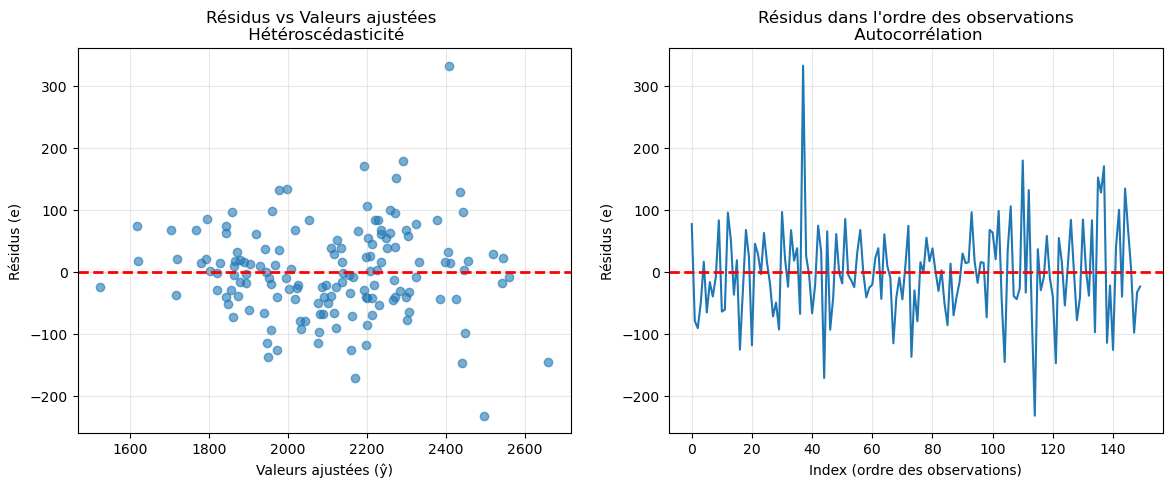

In [134]:
resid = model_origin.resid
fitted = model_origin.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(fitted, resid, alpha = 0.6)
axes[0].axhline(y = 0, color = 'r', linestyle = '--', linewidth = 2 )
axes[0].set_xlabel("Valeurs ajustées (ŷ)")
axes[0].set_ylabel("Résidus (e)")
axes[0].set_title("Résidus vs Valeurs ajustées \n Hétéroscédasticité")
axes[0].grid(True, alpha=0.3)
             
axes[1].plot(resid.values if hasattr(resid, "values") else resid)
axes[1].axhline(y = 0, color = 'r', linestyle = '--', linewidth = 2 )
axes[1].set_xlabel("Index (ordre des observations)")
axes[1].set_ylabel("Résidus (e)")
axes[1].set_title("Résidus dans l'ordre des observations\n Autocorrélation")
axes[1].grid(True, alpha=0.3)

In [135]:
# test de Breusch–Pagan
U2 = U_hat**2
Z = X[:, 1:]   # on enlève la constante
alpha_hat = np.linalg.inv(Z.T @ Z) @ Z.T @ U2
U2_hat = Z @ alpha_hat
SSR_aux = np.sum((U2_hat - U2.mean())**2)
SST_aux = np.sum((U2 - U2.mean())**2)

R2_aux = SSR_aux / SST_aux
LM = len(U2) * R2_aux

p_value = 1 - chi2.cdf(LM, df=Z.shape[1])
print(f'p_value du test de Breusch - Pagan : {p_value:.4f}')

p_value du test de Breusch - Pagan : 0.0068


In [136]:
# matrice SE de White
S = X.T @ (X * U2[:, None])           # (k,k)

#Variance-cov robust HC0
V_hc0 = XtX_inv @ S @ XtX_inv         # (k,k)

#Robust SE + t-stats
se_hc0 = np.sqrt(np.diag(V_hc0))      # (k,)
t_hc0 = (B_hat.reshape(-1) / se_hc0)

se_white = np.sqrt(np.diag(V_hc0))

t_white = B_hat / se_white

# ddl "classique" (approx) : N - k
df_resid = N - k
p_white = 2 * (1 - stats.t.cdf(np.abs(t_white), df=df_resid))

tcrit = stats.t.ppf(0.975, df=df_resid)   # IC 95%
ci_low = B_hat - tcrit * se_white
ci_high = B_hat + tcrit * se_white

print("SE White:", se_white)
print("t White:", t_white)
print("p White:", p_white)

SE White: [1.13005651e+03 2.32914643e-01 6.45822335e+00 5.65269173e-01
 7.48013319e-01 3.40620874e+00 1.20933413e+01 6.76685581e-01
 3.60513423e+00 1.34240033e+01]
t White: [-1.56888637 18.10770508  5.60574465  2.67230347 -9.81481285  2.59265446
  4.20734077  3.63677875  5.89747839  7.72317551]
p White: [1.18931868e-01 0.00000000e+00 1.06581166e-07 8.42743786e-03
 0.00000000e+00 1.05347385e-02 4.59088234e-05 3.87102049e-04
 2.64013740e-08 1.96798133e-12]


In [137]:
# DW test
dw_num = np.sum(np.diff(U_hat)**2)
dw_den = np.sum(U_hat**2)
DW = dw_num / dw_den

print(f"Durbin-Watson = {DW:.4f}")

Durbin-Watson = 2.1020


In [138]:
# écarts-types de Newey-West
L = int(np.floor(4 * (N / 100) ** (2 / 9))) 
S_nw = np.zeros((k, k))

for t in range(N):
    xt = X[t].reshape(k, 1)
    S_nw += (U_hat[t] ** 2) * (xt @ xt.T)

for ell in range(1, L + 1):
    w = 1.0 - ell / (L + 1.0)  # poids de Bartlett
    Gamma = np.zeros((k, k))
    for t in range(ell, N):
        xt = X[t].reshape(k, 1)
        xlag = X[t - ell].reshape(k, 1)
        Gamma += (U_hat[t] * U_hat[t - ell]) * (xt @ xlag.T)
    S_nw += w * (Gamma + Gamma.T)

# 3) Variance-cov HAC et SE/t-stats
V_nw = XtX_inv @ S_nw @ XtX_inv
se_nw = np.sqrt(np.diag(V_nw))
t_nw = (B_hat.reshape(-1) / se_nw)

print(f'ecart type de Newey-West : {se_nw}')


ecart type de Newey-West : [1.11096905e+03 2.21365919e-01 7.42941237e+00 5.53945227e-01
 6.44014574e-01 3.88465221e+00 1.09275396e+01 6.54749122e-01
 4.39516719e+00 1.15176462e+01]


In [139]:
# Comparaison des SE et t de mco, white et newey west

var_names = ["Constante","Surface_m2","Chambres","Annee_construction","Distance_centre_km",
             "Etage","Ascenseur","Revenu_median_quartier","Qualite_ecole","Covid"]

se_mco = model_origin.bse

# t-stats
t_mco = B_hat / se_mco
t_white = B_hat / se_white
t_nw = B_hat / se_nw

# p-values (ddl approx N-k ; pour NW on garde la même approx pour rester cohérent)
p_mco = 2*(1-stats.t.cdf(np.abs(t_mco), df=df_resid))
p_white = 2*(1-stats.t.cdf(np.abs(t_white), df=df_resid))
p_nw = 2*(1-stats.t.cdf(np.abs(t_nw), df=df_resid))

# IC 95% (White)
tcrit = stats.t.ppf(0.975, df=df_resid)
ci_low_w = B_hat - tcrit*se_white
ci_high_w = B_hat + tcrit*se_white

results = pd.DataFrame({
    "coef": B_hat,
    "SE_MCO": se_mco,
    "t_MCO": t_mco,
    "p_MCO": p_mco,
    "SE_White": se_white,
    "t_White": t_white,
    "p_White": p_white,
    "SE_NeweyWest": se_nw,
    "t_NeweyWest": t_nw,
    "p_NeweyWest": p_nw,
    "CI95_White_low": ci_low_w,
    "CI95_White_high": ci_high_w,
}, index=var_names)

print(results.round(4))

                             coef     SE_MCO    t_MCO   p_MCO   SE_White  \
Constante              -1772.9303  1083.7549  -1.6359  0.1041  1130.0565   
Surface_m2                 4.2175     0.2070  20.3707  0.0000     0.2329   
Chambres                  36.2032     7.2291   5.0080  0.0000     6.4582   
Annee_construction         1.5106     0.5408   2.7931  0.0060     0.5653   
Distance_centre_km        -7.3416     0.7103 -10.3353  0.0000     0.7480   
Etage                      8.8311     3.5997   2.4533  0.0154     3.4062   
Ascenseur                 50.8808    12.6946   4.0081  0.0001    12.0933   
Revenu_median_quartier     2.4610     0.8486   2.9002  0.0043     0.6767   
Qualite_ecole             21.2612     4.1943   5.0691  0.0000     3.6051   
Covid                    103.6759    12.9276   8.0198  0.0000    13.4240   

                        t_White  p_White  SE_NeweyWest  t_NeweyWest  \
Constante               -1.5689   0.1189     1110.9691      -1.5958   
Surface_m2           

In [140]:
# Préparation des variables
y = df['Prix_milliers_euros']
X_endog = df['Qualite_ecole']
Z_inst = df['Distance_universite']

# Variables de contrôle (exogènes)
exog_cols = ['Surface_m2', 'Chambres', 'Annee_construction', 'Distance_centre_km', 
             'Etage', 'Ascenseur', 'Revenu_median_quartier', 'Covid']

# Vérification que la constante est bien ajoutée aux contrôles
W = sm.add_constant(df[exog_cols])

# --- ÉTAPE 1 : Validité de l'instrument (First Stage) ---
# On régresse la variable endogène sur l'instrument ET tous les contrôles exogènes
X_step1 = sm.add_constant(pd.concat([Z_inst, df[exog_cols]], axis=1))
model_step1 = sm.OLS(X_endog, X_step1).fit()

print("=== ÉTAPE 1 : RÉGRESSION DE L'INSTRUMENT (Validité) ===")
print(f"Coefficient de Distance_universite : {model_step1.params['Distance_universite']:.4f}")
print(f"P-valeur de l'instrument : {model_step1.pvalues['Distance_universite']:.4f}")
print(f"F-statistic de l'étape 1 : {model_step1.fvalue:.2f}")
print("-" * 50)

# On récupère les valeurs prédites "propres" (X_hat) de la qualité de l'école
df['Qualite_ecole_hat'] = model_step1.predict(X_step1)

# --- ÉTAPE 2 : Calcul matriciel manuel (Second Stage) ---
# Formule du cours : Beta = (X_hat' * X_hat)^-1 * X_hat' * y
# On construit la matrice X finale avec la variable instrumentée et les contrôles
X_final = sm.add_constant(pd.concat([df['Qualite_ecole_hat'], df[exog_cols]], axis=1))

# Conversion en matrices numpy pour l'algèbre matricielle
X_mat = X_final.values
y_mat = y.values

# Calcul de l'estimateur IV : (X'X)^-1 * X'y
beta_iv = np.linalg.inv(X_mat.T @ X_mat) @ (X_mat.T @ y_mat)

# --- AFFICHAGE DES RÉSULTATS ---
# L'ordre des labels doit correspondre à l'ordre des colonnes dans X_final
labels = ['Constante', 'Qualite_ecole (IV)'] + exog_cols
results_manual = pd.Series(beta_iv, index=labels)

print("=== ÉTAPE 2 : COEFFICIENTS IV CALCULÉS ===")
print(results_manual)

=== ÉTAPE 1 : RÉGRESSION DE L'INSTRUMENT (Validité) ===
Coefficient de Distance_universite : -0.1441
P-valeur de l'instrument : 0.0000
F-statistic de l'étape 1 : 12.27
--------------------------------------------------
=== ÉTAPE 2 : COEFFICIENTS IV CALCULÉS ===
Constante                -1637.468593
Qualite_ecole (IV)           0.887505
Surface_m2                   4.291614
Chambres                    34.014596
Annee_construction           1.421282
Distance_centre_km          -7.455514
Etage                        7.653728
Ascenseur                   51.456428
Revenu_median_quartier       4.934581
Covid                      102.895892
dtype: float64


In [141]:
# Préparation des données pour la régularisation
# On utilise les mêmes variables que le modèle complet (sans la constante, sklearn l'ajoute)

X_reg = df[["Surface_m2", "Chambres", "Annee_construction", 
            "Distance_centre_km", "Etage", "Ascenseur",
            "Revenu_median_quartier", "Qualite_ecole", "Covid"]].values

Y_reg = df["Prix_milliers_euros"].values

var_names_reg = ["Surface_m2", "Chambres", "Annee_construction", 
                 "Distance_centre_km", "Etage", "Ascenseur",
                 "Revenu_median_quartier", "Qualite_ecole", "Covid"]

### Standardisation des variables

**Pourquoi standardiser ?** Ridge et Lasso pénalisent les coefficients selon leur magnitude. Sans standardisation, les variables avec grandes échelles auraient des coefficients artificiellement petits, donc moins pénalisés.

**Formule de standardisation :**

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{\sigma_j}$$

Après standardisation : $\bar{z}_j = 0$ et $\sigma_{z_j} = 1$ pour chaque variable $j$.

In [142]:
def standardiser(X):
    """
    Standardise les colonnes de X (moyenne=0, écart-type=1).
    Retourne : X_scaled, moyennes, écarts-types
    """
    moyennes = X.mean(axis=0)
    ecarts_types = X.std(axis=0, ddof=0)  # ddof=0 pour cohérence avec sklearn
    X_scaled = (X - moyennes) / ecarts_types
    return X_scaled, moyennes, ecarts_types

X_scaled, X_moyennes, X_stds = standardiser(X_reg)

print("Vérification de la standardisation :")
print(f"Moyennes : {X_scaled.mean(axis=0).round(10)}")
print(f"Écarts-types : {X_scaled.std(axis=0).round(4)}")

Vérification de la standardisation :
Moyennes : [-0. -0.  0.  0. -0.  0.  0.  0.  0.]
Écarts-types : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 1. Régression Ridge - Évolution des coefficients

**Ridge** ajoute une pénalité L2 (somme des carrés des coefficients) à la fonction de coût MCO :

$$\hat{\beta}_{Ridge} = \arg\min_{\beta} \left\{ \sum_{i=1}^{n}(y_i - x_i'\beta)^2 + \lambda \sum_{j=1}^{p}\beta_j^2 \right\}$$

Ou en notation matricielle :

$$\hat{\beta}_{Ridge} = \arg\min_{\beta} \left\{ \|Y - X\beta\|^2 + \lambda\|\beta\|_2^2 \right\}$$

**Solution analytique (forme fermée) :**

$$\boxed{\hat{\beta}_{Ridge} = (X'X + \lambda I_p)^{-1}X'Y}$$

- Quand $\lambda = 0$ : on retrouve l'estimateur MCO
- Quand $\lambda \to \infty$ : tous les coefficients tendent vers 0

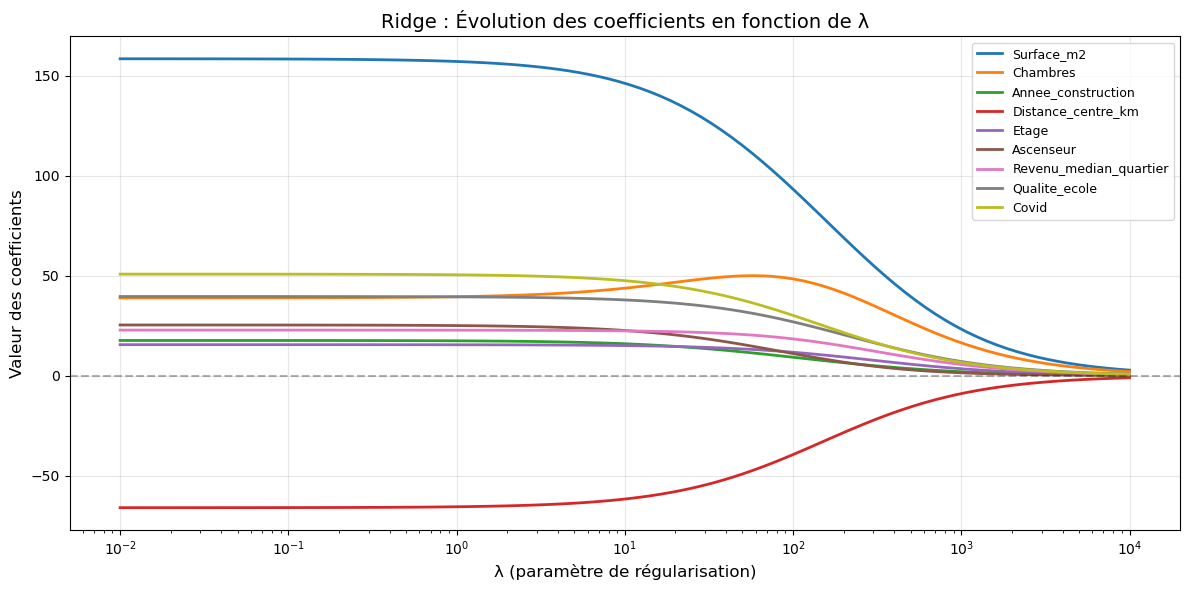

In [143]:
lambdas = np.logspace(-2, 4, 100)  # λ de 0.01 à 10000

# Stockage des coefficients pour chaque λ
ridge_coefs = []

for lam in lambdas:
    ridge = Ridge(alpha=lam, fit_intercept=True)
    ridge.fit(X_scaled, Y_reg)
    ridge_coefs.append(ridge.coef_)

ridge_coefs = np.array(ridge_coefs)

# Graphique
plt.figure(figsize=(12, 6))
for i in range(len(var_names_reg)):
    plt.plot(lambdas, ridge_coefs[:, i], label=var_names_reg[i], linewidth=2)

plt.xscale('log')
plt.xlabel('λ (paramètre de régularisation)', fontsize=12)
plt.ylabel('Valeur des coefficients', fontsize=12)
plt.title('Ridge : Évolution des coefficients en fonction de λ', fontsize=14)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Analyse Ridge :**

On observe sur le graphique que :
- Pour λ faible (≈ 0.01), les coefficients sont proches des valeurs MCO
- Quand λ augmente, tous les coefficients sont progressivement "shrinkés" vers 0
- **Surface_m2** reste le coefficient le plus élevé même pour λ grand, confirmant son importance dans l'explication du prix
- **Distance_centre_km** a un coefficient négatif qui diminue en valeur absolue
- Contrairement à Lasso, Ridge ne met jamais un coefficient exactement à 0 :c'est une régularisation "douce"

### 2. Régression Lasso - Évolution des coefficients

**Lasso** (Least Absolute Shrinkage and Selection Operator) ajoute une pénalité L1 (somme des valeurs absolues) :

$$\hat{\beta}_{Lasso} = \arg\min_{\beta} \left\{ \sum_{i=1}^{n}(y_i - x_i'\beta)^2 + \lambda \sum_{j=1}^{p}|\beta_j| \right\}$$

Ou en notation matricielle :

$$\boxed{\hat{\beta}_{Lasso} = \arg\min_{\beta} \left\{ \|Y - X\beta\|^2 + \lambda\|\beta\|_1 \right\}}$$

**Différence fondamentale avec Ridge :**
- La pénalité L1 n'est **pas différentiable** en $\beta_j = 0$
- Cela crée une **discontinuité** qui permet de mettre certains coefficients **exactement à zéro**
- Lasso effectue donc simultanément **estimation** et **sélection de variables**

**Pas de forme fermée** → résolution par algorithme itératif (descente de coordonnées)

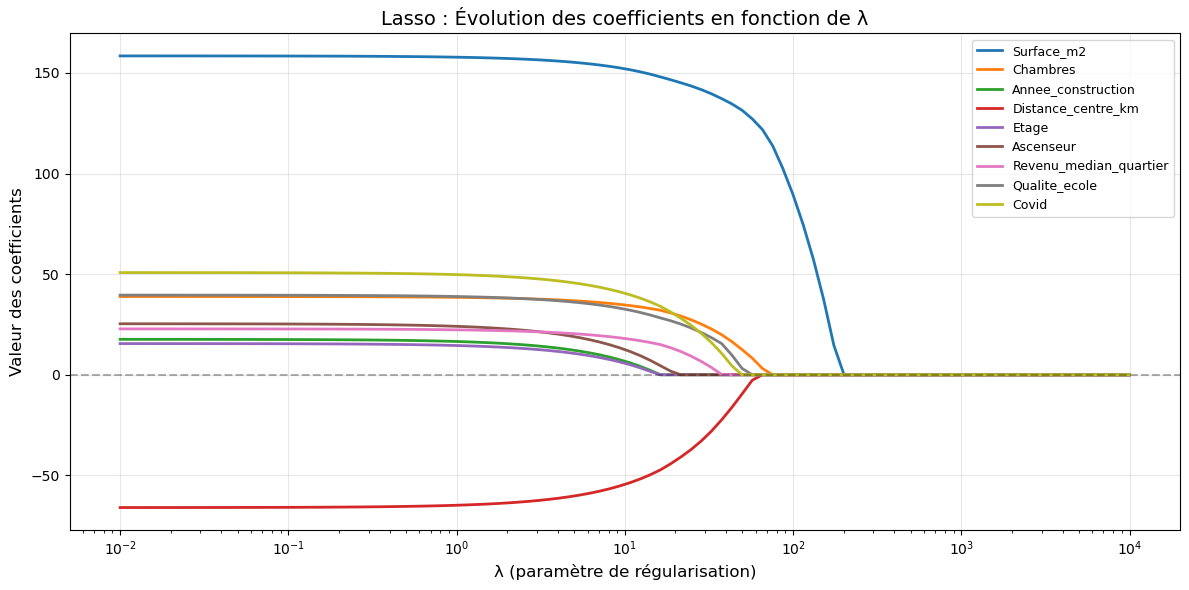

In [144]:
lasso_coefs = []

for lam in lambdas:
    lasso = Lasso(alpha=lam, fit_intercept=True, max_iter=10000)
    lasso.fit(X_scaled, Y_reg)
    lasso_coefs.append(lasso.coef_)

lasso_coefs = np.array(lasso_coefs)

# Graphique
plt.figure(figsize=(12, 6))
for i in range(len(var_names_reg)):
    plt.plot(lambdas, lasso_coefs[:, i], label=var_names_reg[i], linewidth=2)

plt.xscale('log')
plt.xlabel('λ (paramètre de régularisation)', fontsize=12)
plt.ylabel('Valeur des coefficients', fontsize=12)
plt.title('Lasso : Évolution des coefficients en fonction de λ', fontsize=14)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [145]:
# Tableau de sélection des variables selon λ
print("Lasso - Sélection de variables selon λ :")
print(f"{'λ':>10} | {'Coefs ≠ 0':>10} | Variables conservées")
print("-"*70)

for lam in [0.1, 1, 10, 50, 100, 500]:
    lasso = Lasso(alpha=lam, fit_intercept=True, max_iter=10000)
    lasso.fit(X_scaled, Y_reg)
    n_nonzero = np.sum(lasso.coef_ != 0)
    selected = [var_names_reg[i] for i in range(len(var_names_reg)) if lasso.coef_[i] != 0]
    print(f"{lam:>10.1f} | {n_nonzero:>10} | {', '.join(selected) if selected else 'Aucune'}")

Lasso - Sélection de variables selon λ :
         λ |  Coefs ≠ 0 | Variables conservées
----------------------------------------------------------------------
       0.1 |          9 | Surface_m2, Chambres, Annee_construction, Distance_centre_km, Etage, Ascenseur, Revenu_median_quartier, Qualite_ecole, Covid
       1.0 |          9 | Surface_m2, Chambres, Annee_construction, Distance_centre_km, Etage, Ascenseur, Revenu_median_quartier, Qualite_ecole, Covid
      10.0 |          9 | Surface_m2, Chambres, Annee_construction, Distance_centre_km, Etage, Ascenseur, Revenu_median_quartier, Qualite_ecole, Covid
      50.0 |          4 | Surface_m2, Chambres, Distance_centre_km, Qualite_ecole
     100.0 |          1 | Surface_m2
     500.0 |          0 | Aucune


**Analyse Lasso :**
Le comportement de Lasso est fondamentalement différent de Ridge :
- Pour λ faible, les coefficients sont proches de MCO
- Quand λ augmente, certains coefficients deviennent - Les variables disparaissent progressivement : d'abord les moins importantes (ex: Covid, Etage), puis les autres
- **Surface_m2** est la dernière variable à rester non-nulle, confirmant son rôle central
- À λ = 500, seules X variables restent sélectionnées

Cette propriété de parcimonie (sparsity) est la principale différence avec Ridge.

### 3. Validation croisée K-fold pour choisir λ optimal

Le paramètre $\lambda$ contrôle le **compromis biais-variance** :
- $\lambda$ trop petit → surapprentissage (variance élevée)
- $\lambda$ trop grand → sous-apprentissage (biais élevé)

**Validation croisée K-fold** : on divise les données en K parties égales, puis pour chaque valeur de $\lambda$ :

$$\text{CV}(\lambda) = \frac{1}{K}\sum_{k=1}^{K} MSE_k(\lambda)$$

où $MSE_k$ est l'erreur sur le fold $k$ avec un modèle entraîné sur les $K-1$ autres folds.

**Choix optimal :**

$$\lambda^* = \arg\min_{\lambda} \text{CV}(\lambda)$$

In [146]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Ridge CV
ridge_cv_mse = []
for lam in lambdas:
    ridge = Ridge(alpha=lam)
    scores = cross_val_score(ridge, X_scaled, Y_reg, cv=kf, scoring='neg_mean_squared_error')
    ridge_cv_mse.append(-scores.mean())

ridge_cv_mse = np.array(ridge_cv_mse)
lambda_opt_ridge = lambdas[np.argmin(ridge_cv_mse)]

print(f"Ridge - λ optimal : {lambda_opt_ridge:.4f}")
print(f"Ridge - RMSE minimal (CV) : {np.sqrt(np.min(ridge_cv_mse)):.4f}")

# Lasso CV
lasso_cv_mse = []
for lam in lambdas:
    lasso = Lasso(alpha=lam, max_iter=10000)
    scores = cross_val_score(lasso, X_scaled, Y_reg, cv=kf, scoring='neg_mean_squared_error')
    lasso_cv_mse.append(-scores.mean())

lasso_cv_mse = np.array(lasso_cv_mse)
lambda_opt_lasso = lambdas[np.argmin(lasso_cv_mse)]

print(f"Lasso - λ optimal : {lambda_opt_lasso:.4f}")
print(f"Lasso - RMSE minimal (CV) : {np.sqrt(np.min(lasso_cv_mse)):.4f}")

Ridge - λ optimal : 2.0092
Ridge - RMSE minimal (CV) : 79.7275
Lasso - λ optimal : 0.3765
Lasso - RMSE minimal (CV) : 79.7922


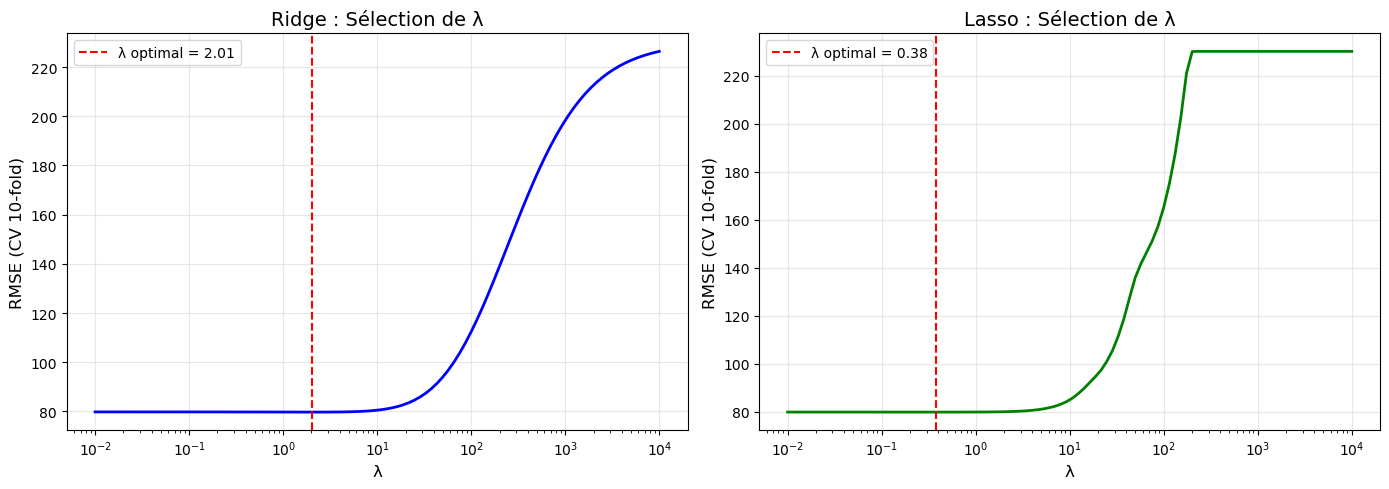

In [147]:
# Graphiques CV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lambdas, np.sqrt(ridge_cv_mse), 'b-', linewidth=2)
axes[0].axvline(x=lambda_opt_ridge, color='r', linestyle='--', 
                label=f'λ optimal = {lambda_opt_ridge:.2f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('λ', fontsize=12)
axes[0].set_ylabel('RMSE (CV 10-fold)', fontsize=12)
axes[0].set_title('Ridge : Sélection de λ', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lambdas, np.sqrt(lasso_cv_mse), 'g-', linewidth=2)
axes[1].axvline(x=lambda_opt_lasso, color='r', linestyle='--', 
                label=f'λ optimal = {lambda_opt_lasso:.2f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('λ', fontsize=12)
axes[1].set_ylabel('RMSE (CV 10-fold)', fontsize=12)
axes[1].set_title('Lasso : Sélection de λ', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [148]:
# Coefficients avec λ optimal
ridge_opt = Ridge(alpha=lambda_opt_ridge).fit(X_scaled, Y_reg)
lasso_opt = Lasso(alpha=lambda_opt_lasso, max_iter=10000).fit(X_scaled, Y_reg)

print("Coefficients avec λ optimal :")
print(f"{'Variable':<25} {'Ridge':>12} {'Lasso':>12}")
print("-"*50)
for i, var in enumerate(var_names_reg):
    print(f"{var:<25} {ridge_opt.coef_[i]:>12.4f} {lasso_opt.coef_[i]:>12.4f}")

Coefficients avec λ optimal :
Variable                         Ridge        Lasso
--------------------------------------------------
Surface_m2                    155.7358     158.2080
Chambres                       40.0638      38.7271
Annee_construction             17.2541      17.2116
Distance_centre_km            -65.0603     -65.5490
Etage                          15.4129      15.1387
Ascenseur                      24.7560      24.8749
Revenu_median_quartier         22.7182      22.6250
Qualite_ecole                  39.2405      39.3223
Covid                          50.0936      50.4032


### 4. Comparaison OLS vs Ridge vs Lasso (Train 80% - Test 20%)

Pour évaluer la performance prédictive, on divise les données en :
- **Échantillon d'entraînement** (80%) : pour estimer les coefficients
- **Échantillon de test** (20%) : pour évaluer la qualité de prédiction

**Métrique d'évaluation :**

$$RMSE = \sqrt{\frac{1}{n_{test}}\sum_{i \in test}(y_i - \hat{y}_i)^2}$$

In [149]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y_reg, test_size=0.2, random_state=42
)

print(f"Taille train : {len(X_train)}, Taille test : {len(X_test)}")

Taille train : 120, Taille test : 30


In [150]:
# Entraînement des 3 modèles
ols = LinearRegression().fit(X_train, y_train)
ridge_final = Ridge(alpha=lambda_opt_ridge).fit(X_train, y_train)
lasso_final = Lasso(alpha=lambda_opt_lasso, max_iter=10000).fit(X_train, y_train)

# Prédictions
y_pred_ols = ols.predict(X_test)
y_pred_ridge = ridge_final.predict(X_test)
y_pred_lasso = lasso_final.predict(X_test)

# RMSE
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

In [151]:
# Tableau récapitulatif
print("="*60)
print("COMPARAISON DES MODÈLES - Erreur sur échantillon TEST")
print("="*60)
n_lasso_vars = np.sum(lasso_final.coef_ != 0)

print(f"{'Modèle':<25} {'RMSE Test':>15} {'Nb variables':>15}")
print("-"*60)
print(f"{'OLS':<25} {rmse_ols:>15.4f} {len(var_names_reg):>15}")
print(f"{'Ridge (λ=' + f'{lambda_opt_ridge:.2f})':<25} {rmse_ridge:>15.4f} {len(var_names_reg):>15}")
print(f"{'Lasso (λ=' + f'{lambda_opt_lasso:.2f})':<25} {rmse_lasso:>15.4f} {n_lasso_vars:>15}")

COMPARAISON DES MODÈLES - Erreur sur échantillon TEST
Modèle                          RMSE Test    Nb variables
------------------------------------------------------------
OLS                               78.2861               9
Ridge (λ=2.01)                    78.3851               9
Lasso (λ=0.38)                    78.1684               9


In [152]:
# Comparaison des coefficients
print("\nComparaison des coefficients (données standardisées) :")
print(f"{'Variable':<25} {'OLS':>10} {'Ridge':>10} {'Lasso':>10}")
print("-"*60)
for i, var in enumerate(var_names_reg):
    print(f"{var:<25} {ols.coef_[i]:>10.4f} {ridge_final.coef_[i]:>10.4f} {lasso_final.coef_[i]:>10.4f}")


Comparaison des coefficients (données standardisées) :
Variable                         OLS      Ridge      Lasso
------------------------------------------------------------
Surface_m2                  154.7896   151.4588   154.4632
Chambres                     47.5422    48.8333    47.3922
Annee_construction           17.9564    17.3625    17.4896
Distance_centre_km          -65.3435   -64.0837   -64.8559
Etage                        15.6203    15.3743    15.2165
Ascenseur                    22.2231    21.3500    21.6664
Revenu_median_quartier       19.3258    19.0846    19.0370
Qualite_ecole                42.2021    41.7406    41.9965
Covid                        55.7343    54.6426    55.2950


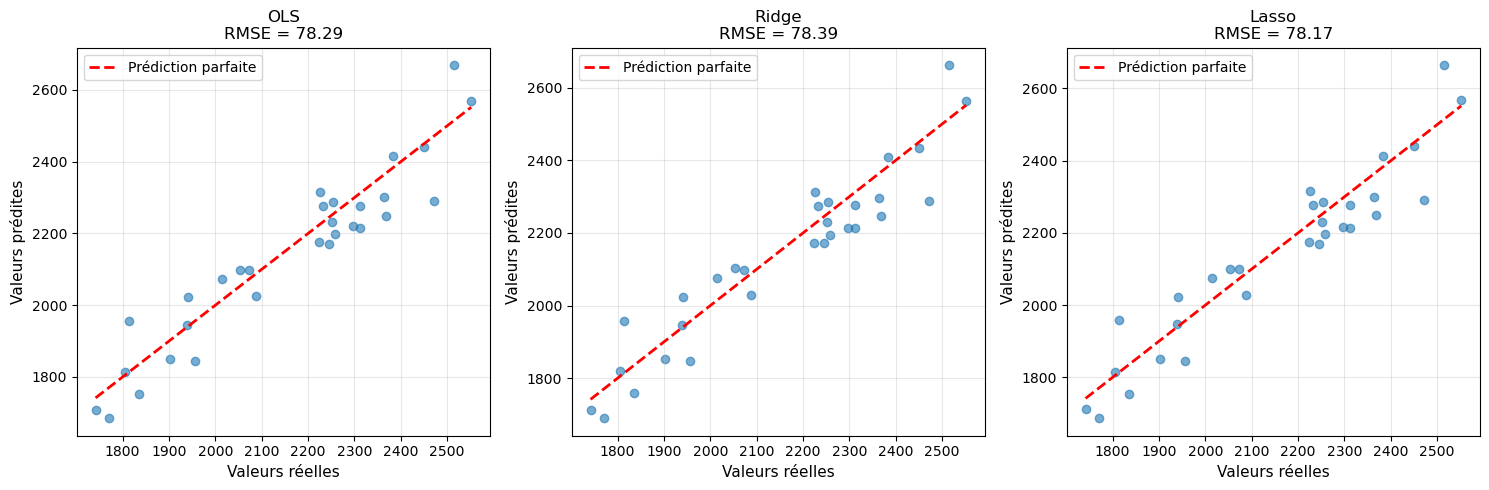

In [153]:
# Graphiques prédictions vs réelles
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_plot = [('OLS', y_pred_ols, rmse_ols), 
               ('Ridge', y_pred_ridge, rmse_ridge), 
               ('Lasso', y_pred_lasso, rmse_lasso)]

for ax, (name, y_pred, rmse) in zip(axes, models_plot):
    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', linewidth=2, label='Prédiction parfaite')
    ax.set_xlabel('Valeurs réelles', fontsize=11)
    ax.set_ylabel('Valeurs prédites', fontsize=11)
    ax.set_title(f'{name}\nRMSE = {rmse:.2f}', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Discussion : Pourquoi les écarts-types classiques ne sont pas valides après Lasso ?

Les écarts-types et tests classiques (t-test, IC) ne sont **PAS valides** après Lasso :

**1. Biais de sélection**

Lasso effectue simultanément estimation ET sélection de variables. Les formules classiques supposent un modèle **fixe**, choisi indépendamment des données. L'incertitude du choix du modèle n'est pas prise en compte.

**2. Distribution non-normale**

Les estimateurs MCO suivent : $\hat{\beta}_{MCO} \sim \mathcal{N}(\beta, \sigma^2(X'X)^{-1})$

Les estimateurs Lasso :
- Sont **biaisés** vers 0 (shrinkage)
- Ont une probabilité non-nulle d'être **exactement à 0**
- Ne suivent pas une loi normale → les tests t et IC gaussiens ne s'appliquent pas

**3. Discontinuité**

Une petite perturbation des données peut faire passer un coefficient de $\hat{\beta}_j \neq 0$ à $\hat{\beta}_j = 0$ (ou inversement).

**4. Sous-estimation de la variance**

Calculer la variance "comme si" les variables avaient été choisies *a priori* sous-estime fortement la vraie variance.

### Résumé : Ridge vs Lasso

| Critère | Ridge | Lasso |
|---------|-------|-------|
| Pénalité | $\lambda\sum_j\beta_j^2$ (L2) | $\lambda\sum_j\|\beta_j\|$ (L1) |
| Solution | Forme fermée | Algorithme itératif |
| Coefficients | Shrinkés vers 0 | Certains exactement = 0 |
| Sélection de variables | Non | Oui |
| Multicolinéarité | Gère bien | Sélectionne une variable parmi les corrélées |
| Interprétabilité | Tous les prédicteurs | Modèle parcimonieux |

## 8. Prévisions
### 8.1 Prédiction ponctuelle et intervalle de confiance

In [154]:
# Caractéristiques de la maison à prédire
x0_dict = {
    "Surface_m2": 120,
    "Chambres": 3,
    "Annee_construction": 2015,
    "Distance_centre_km": 5,
    "Etage": 1,
    "Ascenseur": 1,  # Oui = 1
    "Revenu_median_quartier": 65,  # en milliers (65 000 €)
    "Qualite_ecole": 7,
    "Covid": 0  # Année vente 2023 → pas Covid
}

# Note : "Distance_universite" n'est pas dans notre modèle
print("Caractéristiques de la maison à prédire :")
for var, val in x0_dict.items():
    print(f"  {var}: {val}")

Caractéristiques de la maison à prédire :
  Surface_m2: 120
  Chambres: 3
  Annee_construction: 2015
  Distance_centre_km: 5
  Etage: 1
  Ascenseur: 1
  Revenu_median_quartier: 65
  Qualite_ecole: 7
  Covid: 0


#### 1. Prédiction ponctuelle

In [155]:
# Reconstruction de la matrice X complète (avec constante) pour le modèle OLS
# On reprend les mêmes variables que dans model_origin

X_full = np.column_stack((
    np.ones(N),
    df["Surface_m2"],
    df["Chambres"],
    df["Annee_construction"],
    df["Distance_centre_km"],
    df["Etage"],
    df["Ascenseur"],
    df["Revenu_median_quartier"],
    df["Qualite_ecole"],
    df["Covid"]
))

Y_full = df["Prix_milliers_euros"].values

# Estimation OLS
XtX_inv = np.linalg.inv(X_full.T @ X_full)
B_hat = XtX_inv @ X_full.T @ Y_full

# Vecteur x0 (avec constante)
x0 = np.array([
    1,  # constante
    x0_dict["Surface_m2"],
    x0_dict["Chambres"],
    x0_dict["Annee_construction"],
    x0_dict["Distance_centre_km"],
    x0_dict["Etage"],
    x0_dict["Ascenseur"],
    x0_dict["Revenu_median_quartier"],
    x0_dict["Qualite_ecole"],
    x0_dict["Covid"]
])

# Prédiction ponctuelle
y_hat_0 = x0 @ B_hat

print("="*60)
print("PRÉDICTION PONCTUELLE")
print("="*60)
print(f"\nPrix prédit : {y_hat_0:.2f} milliers d'euros")
print(f"             = {y_hat_0 * 1000:.0f} €")

PRÉDICTION PONCTUELLE

Prix prédit : 2217.38 milliers d'euros
             = 2217380 €


#### 2. Intervalle de confiance à 95%

In [156]:
# Calcul des résidus et estimation de σ²
Y_hat = X_full @ B_hat
U_hat = Y_full - Y_hat
k = X_full.shape[1]  # nombre de paramètres (10)

sigma2_hat = np.sum(U_hat**2) / (N - k)
sigma_hat = np.sqrt(sigma2_hat)

print(f"Estimation de σ : {sigma_hat:.4f} (milliers €)")

Estimation de σ : 76.1091 (milliers €)


In [157]:
# Variance de la prédiction
# Il y a 2 types d'intervalles :
# 
# 1) Intervalle de CONFIANCE pour E[Y|X=x0] :
#    Var(ŷ₀) = σ² · x₀'(X'X)⁻¹x₀
#    → Incertitude sur la MOYENNE conditionnelle
#
# 2) Intervalle de PRÉVISION pour Y₀ :
#    Var(Y₀ - ŷ₀) = σ² · (1 + x₀'(X'X)⁻¹x₀)
#    → Incertitude sur une NOUVELLE observation (inclut l'erreur ε₀)

# Terme quadratique
quad_term = x0 @ XtX_inv @ x0

# Variance pour l'intervalle de confiance (moyenne)
var_conf = sigma2_hat * quad_term
se_conf = np.sqrt(var_conf)

# Variance pour l'intervalle de prévision (nouvelle obs)
var_pred = sigma2_hat * (1 + quad_term)
se_pred = np.sqrt(var_pred)

# t critique à 95%
t_crit = stats.t.ppf(0.975, N - k)

# Intervalles
IC_conf = (y_hat_0 - t_crit * se_conf, y_hat_0 + t_crit * se_conf)
IC_pred = (y_hat_0 - t_crit * se_pred, y_hat_0 + t_crit * se_pred)

print("="*60)
print("INTERVALLES À 95%")
print("="*60)

print(f"\n1) Intervalle de CONFIANCE pour E[Y|X=x₀] :")
print(f"   [{IC_conf[0]:.2f} ; {IC_conf[1]:.2f}] milliers €")
print(f"   = [{IC_conf[0]*1000:.0f} € ; {IC_conf[1]*1000:.0f} €]")
print(f"   Largeur : {(IC_conf[1] - IC_conf[0])*1000:.0f} €")

print(f"\n2) Intervalle de PRÉVISION pour Y₀ :")
print(f"   [{IC_pred[0]:.2f} ; {IC_pred[1]:.2f}] milliers €")
print(f"   = [{IC_pred[0]*1000:.0f} € ; {IC_pred[1]*1000:.0f} €]")
print(f"   Largeur : {(IC_pred[1] - IC_pred[0])*1000:.0f} €")

INTERVALLES À 95%

1) Intervalle de CONFIANCE pour E[Y|X=x₀] :
   [2183.70 ; 2251.05] milliers €
   = [2183705 € ; 2251055 €]
   Largeur : 67350 €

2) Intervalle de PRÉVISION pour Y₀ :
   [2063.19 ; 2371.57] milliers €
   = [2063186 € ; 2371574 €]
   Largeur : 308388 €


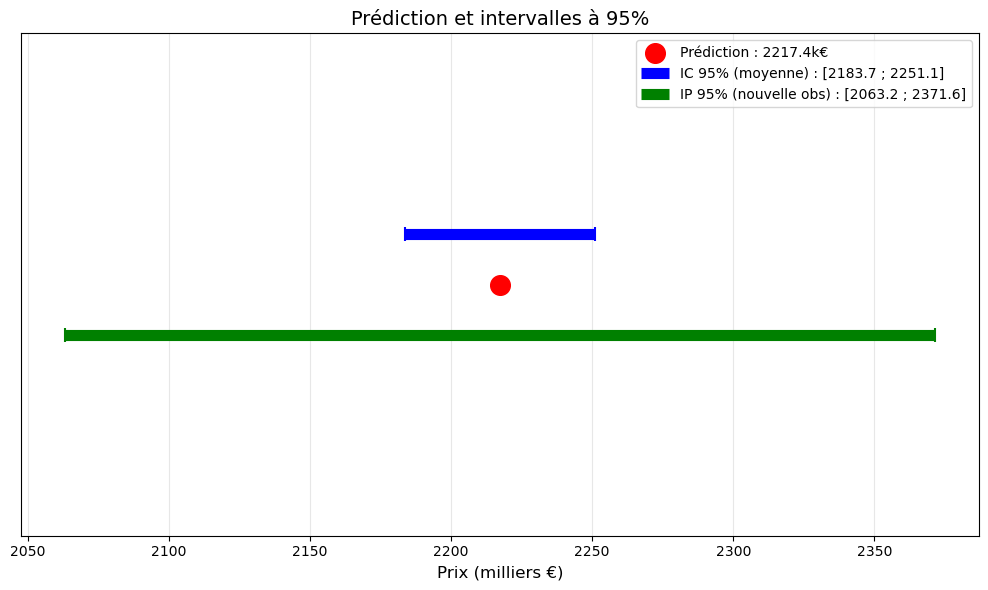

In [158]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))

# Point de prédiction
ax.scatter([y_hat_0], [0], s=200, c='red', zorder=5, label=f'Prédiction : {y_hat_0:.1f}k€')

# Intervalle de confiance
ax.hlines(y=0.1, xmin=IC_conf[0], xmax=IC_conf[1], colors='blue', linewidth=8, 
          label=f'IC 95% (moyenne) : [{IC_conf[0]:.1f} ; {IC_conf[1]:.1f}]')
ax.scatter([IC_conf[0], IC_conf[1]], [0.1, 0.1], s=100, c='blue', marker='|')

# Intervalle de prévision
ax.hlines(y=-0.1, xmin=IC_pred[0], xmax=IC_pred[1], colors='green', linewidth=8, 
          label=f'IP 95% (nouvelle obs) : [{IC_pred[0]:.1f} ; {IC_pred[1]:.1f}]')
ax.scatter([IC_pred[0], IC_pred[1]], [-0.1, -0.1], s=100, c='green', marker='|')

ax.set_ylim(-0.5, 0.5)
ax.set_xlabel('Prix (milliers €)', fontsize=12)
ax.set_title('Prédiction et intervalles à 95%', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_yticks([])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

#### 3. Discussion : Cette prédiction est-elle fiable ?

In [159]:
#### 3. Discussion : Cette prédiction est-elle fiable ?

# ---------------------------------------------------------------------
# A. QUALITÉ GLOBALE DU MODÈLE
# ---------------------------------------------------------------------

# Calcul R² et R² ajusté
SS_res = np.sum(U_hat**2)
SS_tot = np.sum((Y_full - Y_full.mean())**2)
R2 = 1 - SS_res / SS_tot
R2_adj = 1 - (SS_res / (N - k)) / (SS_tot / (N - 1))

print("="*70)
print("A. QUALITÉ GLOBALE DU MODÈLE")
print("="*70)
print(f"R²        : {R2:.4f} ({R2*100:.1f}% de la variance expliquée)")
print(f"R² ajusté : {R2_adj:.4f}")
print(f"σ̂         : {sigma_hat:.2f} milliers € ({sigma_hat/y_hat_0*100:.1f}% du prix prédit)")

# ---------------------------------------------------------------------
# B. VÉRIFICATION DE L'EXTRAPOLATION UNIVARIÉE
# ---------------------------------------------------------------------

print("\n" + "="*70)
print("B. EXTRAPOLATION UNIVARIÉE")
print("="*70)
print(f"{'Variable':<25} {'Min':>10} {'x₀':>10} {'Max':>10} {'Statut':>12}")
print("-"*70)

var_names_check = ["Surface_m2", "Chambres", "Annee_construction", 
                   "Distance_centre_km", "Etage", "Ascenseur",
                   "Revenu_median_quartier", "Qualite_ecole"]

variables_hors_plage = []
for var in var_names_check:
    val = x0_dict[var]
    min_val = df[var].min()
    max_val = df[var].max()
    in_range = min_val <= val <= max_val
    status = "✓ OK" if in_range else "✗ HORS PLAGE"
    if not in_range:
        variables_hors_plage.append(var)
    print(f"{var:<25} {min_val:>10.1f} {val:>10.1f} {max_val:>10.1f} {status:>12}")

if len(variables_hors_plage) == 0:
    print("\n→ Toutes les variables sont dans la plage des données d'entraînement.")
else:
    print(f"\n→ ATTENTION : Variables hors plage : {', '.join(variables_hors_plage)}")

# ---------------------------------------------------------------------
# C. VÉRIFICATION DE L'EXTRAPOLATION MULTIVARIÉE (LEVERAGE)
# ---------------------------------------------------------------------

print("\n" + "="*70)
print("C. EXTRAPOLATION MULTIVARIÉE (LEVERAGE)")
print("="*70)

h_00 = x0 @ XtX_inv @ x0
leverage_seuil = 2 * k / N

print(f"Leverage h₀₀ = x₀'(X'X)⁻¹x₀ : {h_00:.6f}")
print(f"Seuil critique (2k/n)       : {leverage_seuil:.6f}")

if h_00 < leverage_seuil:
    print("→ h₀₀ < 2k/n : Pas d'extrapolation multivariée détectée.")
else:
    print("→ h₀₀ ≥ 2k/n : ATTENTION - Point atypique, extrapolation risquée.")

# ---------------------------------------------------------------------
# D. PRÉCISION DES INTERVALLES
# ---------------------------------------------------------------------

print("\n" + "="*70)
print("D. PRÉCISION DE LA PRÉDICTION")
print("="*70)

largeur_IC = IC_conf[1] - IC_conf[0]
largeur_IP = IC_pred[1] - IC_pred[0]

print(f"Prix prédit : {y_hat_0*1000:,.0f} €")
print(f"\nIntervalle de confiance (95%) : [{IC_conf[0]*1000:,.0f} € ; {IC_conf[1]*1000:,.0f} €]")
print(f"   Largeur : {largeur_IC*1000:,.0f} € ({largeur_IC/y_hat_0*100:.1f}% du prix)")
print(f"\nIntervalle de prévision (95%) : [{IC_pred[0]*1000:,.0f} € ; {IC_pred[1]*1000:,.0f} €]")
print(f"   Largeur : {largeur_IP*1000:,.0f} € ({largeur_IP/y_hat_0*100:.1f}% du prix)")

# ---------------------------------------------------------------------
# E. VERDICT FINAL
# ---------------------------------------------------------------------

print("\n" + "="*70)
print("E. VERDICT FINAL")
print("="*70)

problemes = []
if R2_adj < 0.6:
    problemes.append("R² ajusté faible")
if len(variables_hors_plage) > 0:
    problemes.append(f"extrapolation univariée")
if h_00 >= leverage_seuil:
    problemes.append("leverage élevé")
if largeur_IP / y_hat_0 > 0.25:
    problemes.append("intervalle de prévision large (>25%)")

if len(problemes) == 0:
    print("PRÉDICTION FIABLE")
    print(f"\nLe modèle explique {R2_adj*100:.1f}% de la variance (R² ajusté).")
    print(f"Le point x₀ n'est pas atypique (h₀₀ = {h_00:.4f} < {leverage_seuil:.4f}).")
    print(f"L'intervalle de prévision représente {largeur_IP/y_hat_0*100:.1f}% du prix prédit.")
    print(f"\n→ Prix estimé : {y_hat_0*1000:,.0f} €")
    print(f"→ Fourchette réaliste (95%) : {IC_pred[0]*1000:,.0f} € - {IC_pred[1]*1000:,.0f} €")
else:
    print("PRÉDICTION AVEC RÉSERVES")
    print(f"\nProblèmes détectés : {', '.join(problemes)}")
    print(f"\n→ Prix estimé : {y_hat_0*1000:,.0f} € (à interpréter avec prudence)")

A. QUALITÉ GLOBALE DU MODÈLE
R²        : 0.8970 (89.7% de la variance expliquée)
R² ajusté : 0.8904
σ̂         : 76.11 milliers € (3.4% du prix prédit)

B. EXTRAPOLATION UNIVARIÉE
Variable                         Min         x₀        Max       Statut
----------------------------------------------------------------------
Surface_m2                      15.2      120.0      218.5         ✓ OK
Chambres                         1.0        3.0        5.0         ✓ OK
Annee_construction            1980.0     2015.0     2022.0         ✓ OK
Distance_centre_km               0.8        5.0       30.0         ✓ OK
Etage                            0.0        1.0        5.0         ✓ OK
Ascenseur                        0.0        1.0        1.0         ✓ OK
Revenu_median_quartier          42.9       65.0       83.9         ✓ OK
Qualite_ecole                    1.0        7.0       10.0         ✓ OK

→ Toutes les variables sont dans la plage des données d'entraînement.

C. EXTRAPOLATION MULTIVARIÉE 